✅ 数据处理完成
        Date Close/Last    Volume     Open     High     Low   Close    Return
0 2026-03-23    $251.49  40546110  253.970  254.600  250.28  251.49       NaN
1 2026-03-24    $251.64  45152290  250.350  254.825  249.55  251.64  0.000596
2 2026-03-25    $252.62  28476670  254.095  255.000  251.60  252.62  0.003894
3 2026-03-26    $252.89  41796650  252.115  257.000  250.77  252.89  0.001069
4 2026-03-27    $248.80  47900000  253.900  255.493  248.07  248.80 -0.016173


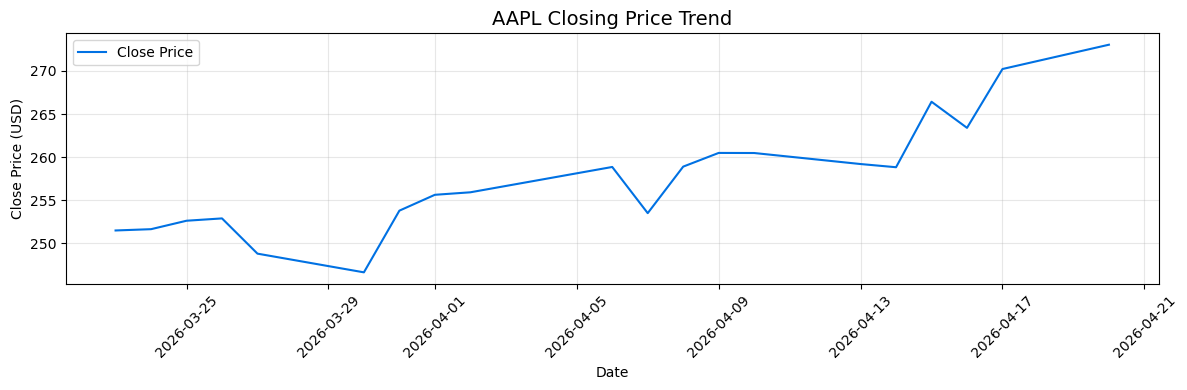

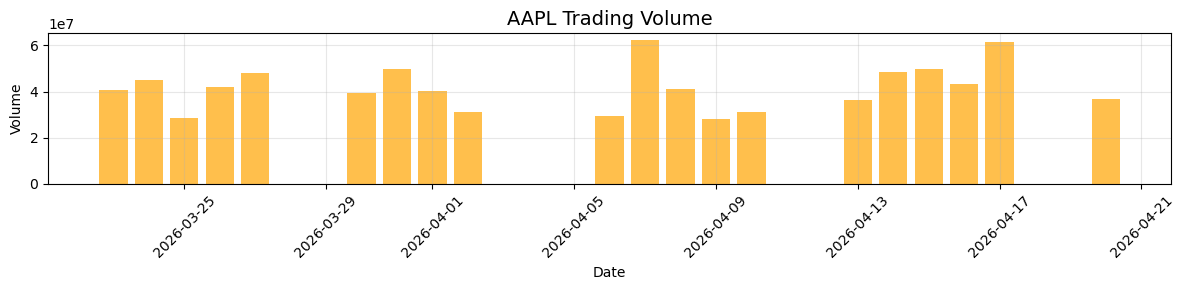


===== 基础统计分析 =====
平均收盘价： 257.64
收盘价标准差： 6.84
平均日收益率： 0.0044
日收益率标准差： 0.0144
最大收盘价： 273.05
最小收盘价： 246.63


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# 1. 读取你的 CSV 数据
# ----------------------
df = pd.read_csv("HistoricalData_1776773023853.csv")

# ----------------------
# 2. 处理日期、清洗格式
# ----------------------
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df = df.sort_values("Date").reset_index(drop=True)

# 去掉价格里的 $ 符号，转成数字
df["Close"] = df["Close/Last"].str.replace("$", "").astype(float)
df["Open"] = df["Open"].str.replace("$", "").astype(float)
df["High"] = df["High"].str.replace("$", "").astype(float)
df["Low"] = df["Low"].str.replace("$", "").astype(float)

# ----------------------
# 3. 计算日收益率
# ----------------------
df["Return"] = df["Close"].pct_change()

# ----------------------
# 4. 输出数据预览
# ----------------------
print("✅ 数据处理完成")
print(df.head())

# ----------------------
# 5. 画图 1：收盘价走势
# ----------------------
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Close"], color="#0071e3", linewidth=1.5, label="Close Price")
plt.title("AAPL Closing Price Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------
# 6. 画图 2：成交量
# ----------------------
plt.figure(figsize=(12, 3))
plt.bar(df["Date"], df["Volume"], color="orange", alpha=0.7)
plt.title("AAPL Trading Volume", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------
# 7. 基础统计分析（作业必写）
# ----------------------
print("\n===== 基础统计分析 =====")
print("平均收盘价：", round(df["Close"].mean(), 2))
print("收盘价标准差：", round(df["Close"].std(), 2))
print("平均日收益率：", round(df["Return"].mean(), 4))
print("日收益率标准差：", round(df["Return"].std(), 4))
print("最大收盘价：", df["Close"].max())
print("最小收盘价：", df["Close"].min())